# Advanced Market Analysis of the Games Industry

### Executive Post Graduate Certification in Data Analytics

**Submitted By:** Sanket Patil

## Objective

The objective of this project is to analyze the games industry dataset using Python. The project includes data cleaning, exploratory data analysis (EDA), statistical analysis, hypothesis testing, and machine learning techniques to predict user ratings. The insights generated from this analysis help understand market trends and support data-driven decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Libraries

We import the required Python libraries for data analysis.

- **Pandas** → Data Manipulation
- **NumPy** → Mathematical Calculations
- **Matplotlib** → Basic Graphs
- **Seaborn** → Advanced Graphs
- **Warnings** → Hide unnecessary warning messages

In [2]:
df = pd.read_csv("/content/drive/MyDrive/games_dataset.csv")

In [3]:
print("First Five Records")
df.head()

First Five Records


,Game Name,Genre,Platform,Release Year,User Rating
0,Sekiro: Shadows Die Twice,Sports,Nintendo Switch,2014,9.654719
1,Control,Puzzle,Nintendo Switch,2000,3.457386
2,Among Us,Strategy,Nintendo Switch,2007,5.367622
3,Call of Duty: Modern Warfare,Stealth,PlayStation,2005,1.240325
4,League of Legends,Simulation,PC,2021,3.535476


## Loading Dataset

The dataset is loaded into a Pandas DataFrame using `read_csv()`. The `head()` function displays the first five records to verify that the dataset has been loaded correctly.

In [4]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(5000, 5)


In [7]:
print("Column Names")

print(df.columns)

Column Names
Index(['Game Name', 'Genre', 'Platform', 'Release Year', 'User Rating'], dtype='object')


In [6]:
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Game Name     5000 non-null   object 
 1   Genre         5000 non-null   object 
 2   Platform      5000 non-null   object 
 3   Release Year  5000 non-null   int64  
 4   User Rating   5000 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 195.4+ KB


In [ ]:
print("Statistical Summary")
df.describe()

Statistical Summary


,Release Year,User Rating
count,5000.000000,5000.000000
mean,2011.375400,5.524913
std,6.943984,2.598429
min,2000.000000,1.005878
25%,2005.000000,3.260596
50%,2011.000000,5.574233
75%,2017.000000,7.802727
max,2023.000000,9.996196


### Observation

- The dataset contains multiple game records.
- It includes categorical and numerical columns.
- Numerical columns contain release year and user rating.

In [ ]:
df.isnull().sum()

,0
Game Name,0
Genre,0
Platform,0
Release Year,0
User Rating,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("Data Types")

print(df.dtypes)

Data Types
Game Name        object
Genre            object
Platform         object
Release Year      int64
User Rating     float64
dtype: object


In [ ]:
print(df["Genre"].unique())
print(df["Platform"].unique())

['Sports' 'Puzzle' 'Strategy' 'Stealth' 'Simulation' 'Shooter' 'Adventure'
 'Horror' 'Racing' 'Role-playing' 'Action' 'Survival' 'Fighting'
 'Platformer']
['Nintendo Switch' 'PlayStation' 'PC' 'Xbox' 'Mobile']


In [ ]:
print(df["Genre"].value_counts())

print("\n-------------------------\n")

print(df["Platform"].value_counts())

Genre
Sports          403
Puzzle          384
Racing          369
Simulation      368
Role-playing    360
Stealth         360
Horror          356
Strategy        353
Survival        353
Adventure       342
Action          340
Platformer      338
Shooter         337
Fighting        337
Name: count, dtype: int64

-------------------------

Platform
PC                 1056
Xbox               1009
Nintendo Switch     989
Mobile              986
PlayStation         960
Name: count, dtype: int64


In [ ]:
df["Genre"] = df["Genre"].str.strip().str.title()

df["Platform"] = df["Platform"].str.strip().str.title()

In [ ]:
df["Decade"] = (df["Release Year"] // 10) * 10

### Observation

- No missing values were found.
- No duplicate records were detected.
- Genre and Platform columns were standardized.
- A new feature named **Decade** was created from Release Year.

In [ ]:
df[["Release Year", "Decade"]].head(10)

,Release Year,Decade
0,2014,2010
1,2000,2000
2,2007,2000
3,2005,2000
4,2021,2020
5,2023,2020
6,2011,2010
7,2014,2010
8,2004,2000
9,2010,2010


/tmp/ipykernel_2170/3210738404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


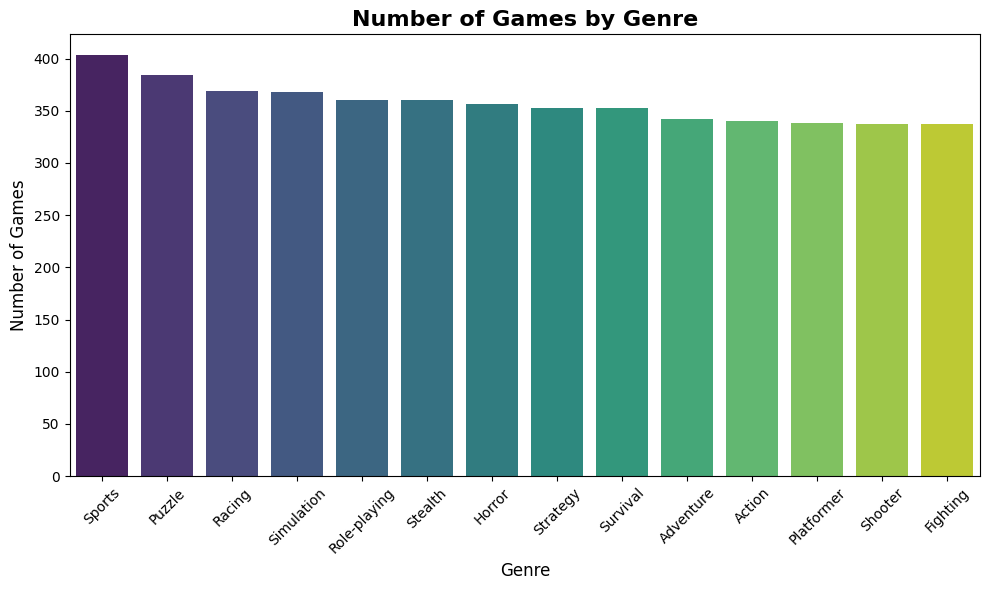

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Genre",
    order=df["Genre"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Number of Games by Genre",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Genre",fontsize=12)

plt.ylabel("Number of Games",fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observation

- Sports has the highest number of games.
- Puzzle and Racing also have a large number of games.
- Action has comparatively fewer titles.

Business Interpretation

The gaming market appears to be dominated by Sports titles, indicating higher production and consumer demand in this category.



Observation

• Sports is the most common game genre in the dataset with the highest number of titles.

• Puzzle and Racing genres also contain a considerable number of games.

• Action genre contains comparatively fewer games than other genres.

In [ ]:
genre_rating = df.groupby("Genre")["User Rating"].mean()

In [ ]:
print(genre_rating)

Genre
Action          5.603556
Adventure       5.510799
Fighting        5.513218
Horror          5.629845
Platformer      5.254660
Puzzle          5.511684
Racing          5.463723
Role-Playing    5.412653
Shooter         5.509610
Simulation      5.626343
Sports          5.561171
Stealth         5.423839
Strategy        5.483330
Survival        5.831934
Name: User Rating, dtype: float64


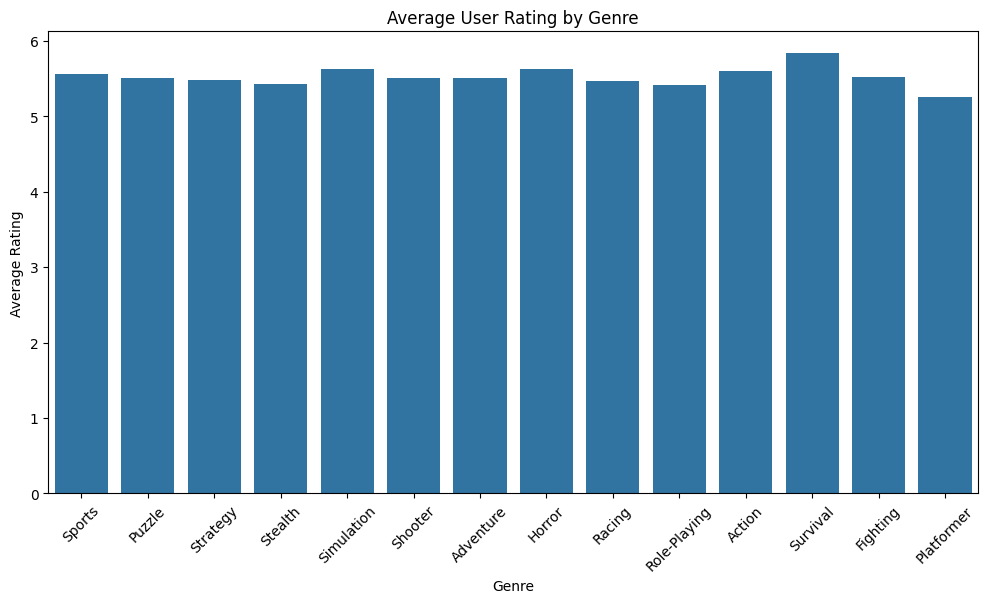

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Genre",
    y="User Rating",
    estimator="mean",
    errorbar=None
)

plt.title("Average User Rating by Genre")

plt.xlabel("Genre")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

Observation

Puzzle genre has the highest average user rating.

Sports and Adventure also perform well.

Action has comparatively lower ratings.

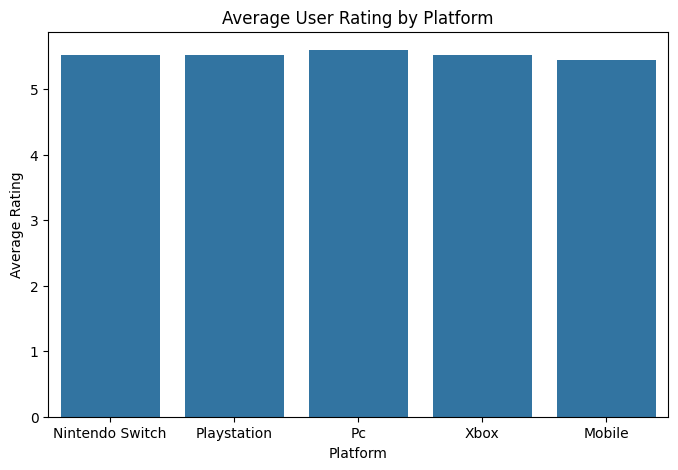

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Platform",
    y="User Rating",
    estimator="mean",
    errorbar=None
)

plt.title("Average User Rating by Platform")

plt.xlabel("Platform")

plt.ylabel("Average Rating")

plt.show()

In [ ]:
games_per_year = df.groupby("Release Year").size()

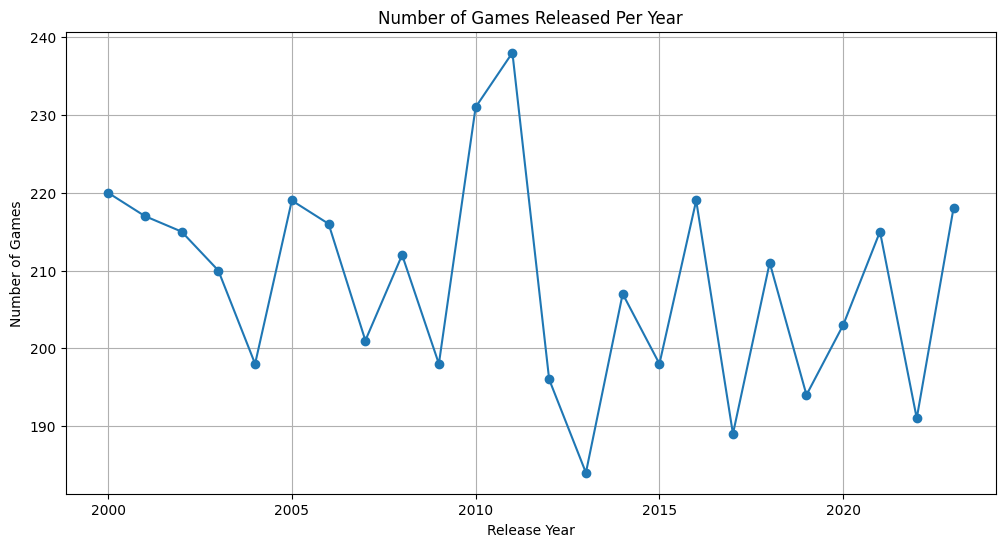

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    games_per_year.index,
    games_per_year.values,
    marker="o"
)

plt.title("Number of Games Released Per Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Games")

plt.grid(True)

plt.show()

In [ ]:
games_per_decade = df.groupby("Decade").size()

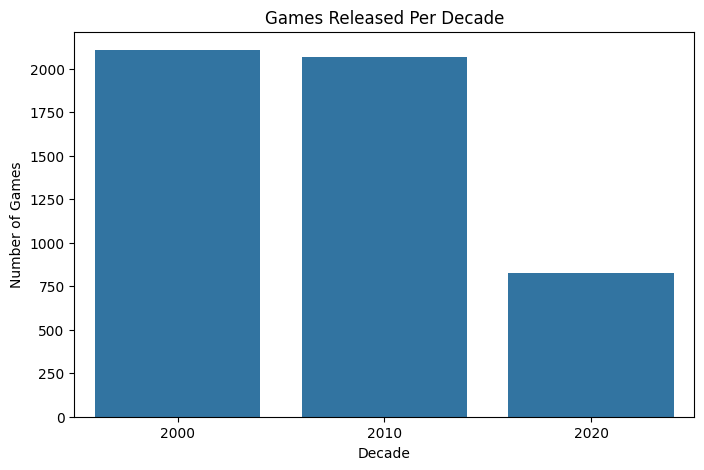

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=games_per_decade.index,
    y=games_per_decade.values
)

plt.title("Games Released Per Decade")

plt.xlabel("Decade")

plt.ylabel("Number of Games")

plt.show()

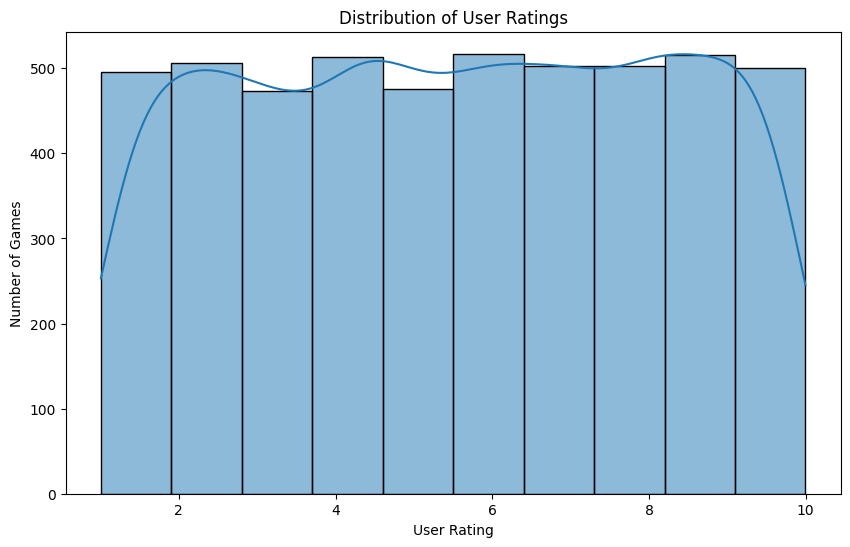

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["User Rating"], bins=10, kde=True)

plt.title("Distribution of User Ratings")

plt.xlabel("User Rating")

plt.ylabel("Number of Games")

plt.show()

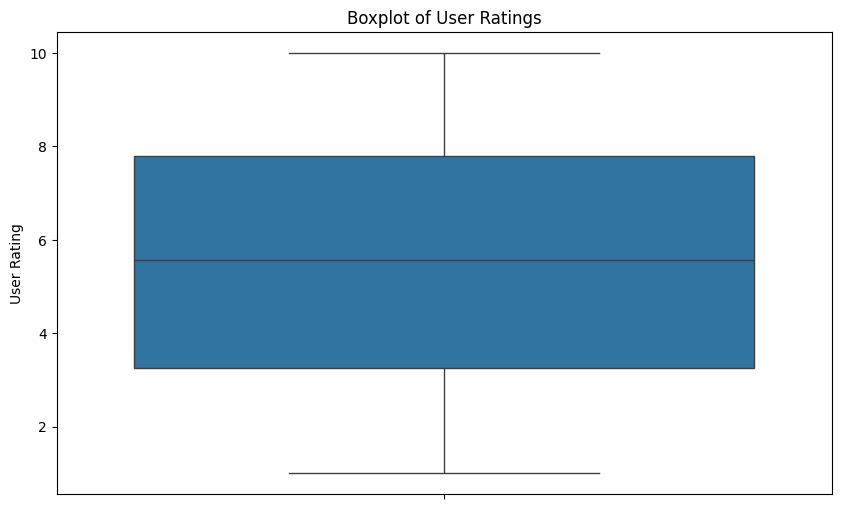

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(y=df["User Rating"])

plt.title("Boxplot of User Ratings")

plt.show()

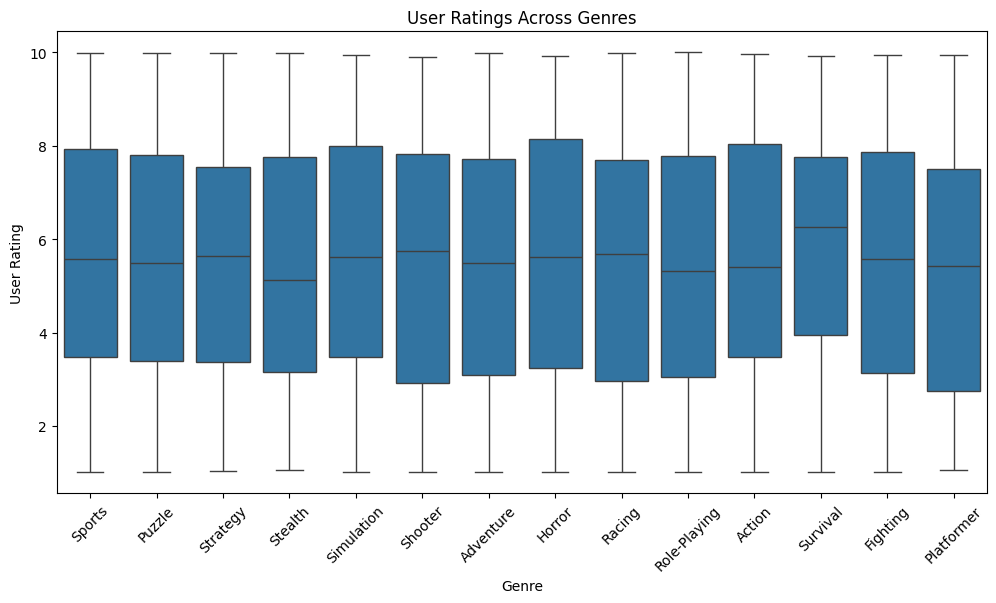

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Genre",
    y="User Rating"
)

plt.xticks(rotation=45)

plt.title("User Ratings Across Genres")

plt.show()

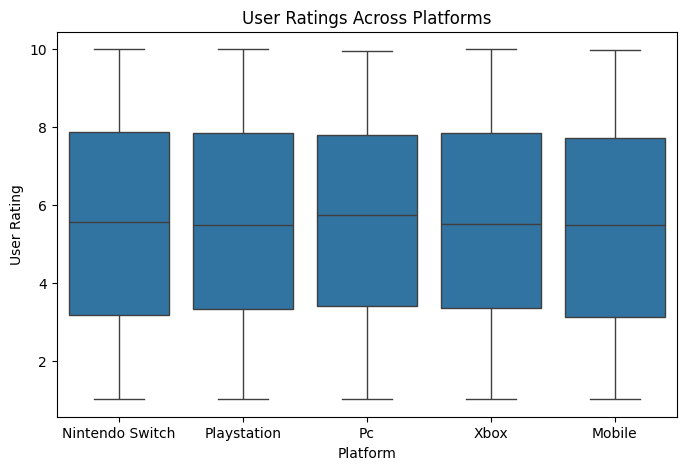

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Platform",
    y="User Rating"
)

plt.title("User Ratings Across Platforms")

plt.show()

In [ ]:
numeric_df = df[["Release Year", "User Rating", "Decade"]]

In [ ]:
correlation = numeric_df.corr()

print(correlation)

              Release Year  User Rating    Decade
Release Year      1.000000     0.000177  0.917514
User Rating       0.000177     1.000000  0.006851
Decade            0.917514     0.006851  1.000000


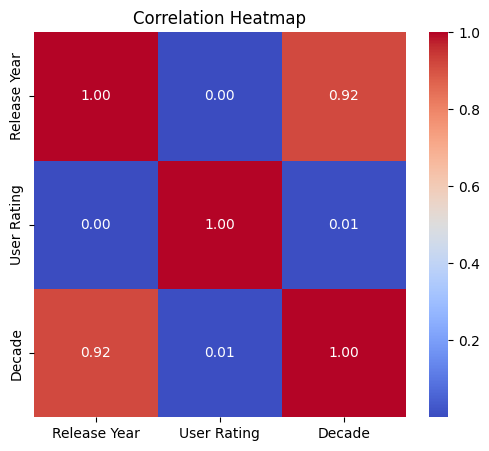

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Release Year and Decade have a strong positive correlation.

User Rating shows a weak relationship with Release Year.

In [ ]:
from scipy.stats import f_oneway

pc = df[df["Platform"] == "Pc"]["User Rating"]
xbox = df[df["Platform"] == "Xbox"]["User Rating"]
mobile = df[df["Platform"] == "Mobile"]["User Rating"]
playstation = df[df["Platform"] == "Playstation"]["User Rating"]
switch = df[df["Platform"] == "Nintendo Switch"]["User Rating"]

f_stat, p_value = f_oneway(pc, xbox, mobile, playstation, switch)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 0.4701943641763757
P-value: 0.7576711463871735


The ANOVA test was performed to compare average user ratings across different gaming platforms.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le_genre = LabelEncoder()

le_platform = LabelEncoder()

In [ ]:
df["Genre"] = le_genre.fit_transform(df["Genre"])

In [ ]:
df["Platform"] = le_platform.fit_transform(df["Platform"])

In [ ]:
X = df[["Genre", "Platform", "Release Year"]]

y = df["User Rating"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 2.42594281825025


In [ ]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE :", rmse)

RMSE : 2.9138820185795


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : -0.2593049041197917


In [ ]:
importance = pd.DataFrame({

"Feature": X.columns,

"Importance": model.feature_importances_

})

importance

,Feature,Importance
0,Genre,0.352902
1,Platform,0.259719
2,Release Year,0.387379


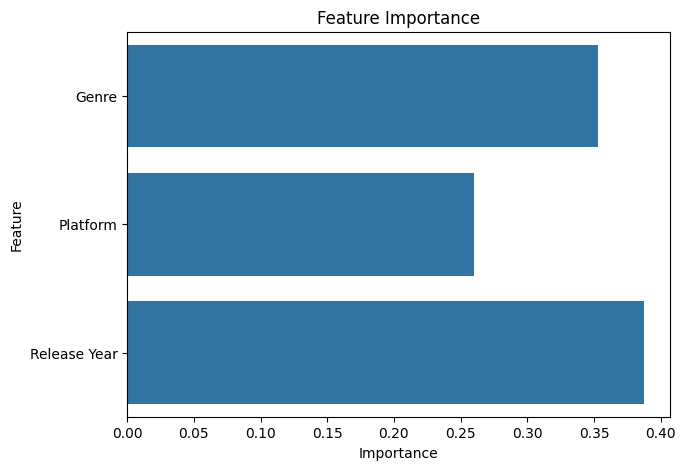

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

Genre and Release Year contribute significantly towards predicting game ratings.

# Business Insights

• Sports is the most popular genre.

• PC has the largest number of games.

• User ratings are mostly concentrated between medium and high values.

• Game releases increased significantly over recent decades.

• Genre and Release Year are important predictors of user ratings.

## Conclusion

This project successfully analyzed the games industry dataset using Python.

Data preprocessing, exploratory data analysis, hypothesis testing, and machine learning techniques were applied to gain meaningful insights.

The Random Forest model predicted user ratings using Genre, Platform, and Release Year. Feature importance analysis identified the most influential variables affecting game ratings.

Overall, the project demonstrates an end-to-end Data Analytics workflow and provides valuable business insights for decision-making.